# Estimate $k_F$ and $k_M$

## 1. Set up the notebook

Do imports.

In [65]:
import numpy as np
import matplotlib.pyplot as plt
from ae483.tools import *
from ae483.mytools import *

## 2. Define constants

Define the acceleration of gravity in $\text{m} \;/\; \text{s}^2$:

In [66]:
g = 9.81

Define the mass of the drone in $\text{kg}$:

In [67]:
m = 32*1e-3 # kg

Define the principle moment of inertia about the $z$ axis in $\text{kg}\cdot\text{m}^2$:

In [68]:
J_z = 0.000005347 # kg m^2

Using a ruler, measure the distance $\ell$ in **meters** along both the $x_B$ and $y_B$ axis from the center of mass to the center of each rotor. The position of the front-right rotor, for example, would then be expressed in the coordinates of the body-frame as

$$p^B_1 = \begin{bmatrix} \ell \\ -\ell \\ 0 \end{bmatrix}.$$

In [69]:
l = 0.0318 # m

## 3. Find the force parameter

### 3.1 Describe the flight

**Modify the text in this cell** to give a precise description of the flight trajectory, both in words and with the relevant code from `flight.py` (i.e., the sequence of stop and move commands). Please include code in markdown with a "code block" that is delimited by three backslashes above and below — for example, this...


```python
# Test #1
    hover_height = 0.50
    increment = 0.01
    for i in range(0, 10):
        displacement = increment * i + 0.01

        print(f"Test #{i}: ±{displacement:.2f} m")

        # Move up
        drone_client.move(0.0, 0.0, hover_height + displacement, 0.0, 2.0)

        # Move down
        drone_client.move(0.0, 0.0, hover_height - displacement, 0.0, 2.0)

        # Return to hover
        drone_client.move(0.0, 0.0, hover_height, 0.0, 2.0)
```

...is rendered like this:
```python
drone_client.move(0.0, 0.0, 0.5, 0.0, 1.0)
```

### 3.2 Get and plot flight data

Load and resample data.

In [70]:
# Load data
raw_data_drone, raw_data_mocap, raw_data_bodies = load_hardware_data('force_data.json')

# Resample data
data_drone = resample_data_drone(
    raw_data_drone,
    t_min_offset=15.,    # <-- FIXME
    t_max_offset=15.,    # <-- FIXME
)

Parse data to get:
* time
* the accelerometer measurements (**note!** these are in units of "$g$'s")
* the motor power commands

In [71]:
t = data_drone['time']
a_x = g * data_drone['acc.x']
a_y = g * data_drone['acc.y']
a_z = g * data_drone['acc.z']
m_1 = data_drone['motor.m1']
m_2 = data_drone['motor.m2']
m_3 = data_drone['motor.m3']
m_4 = data_drone['motor.m4']

Plot accelerometer measurements and motor power commands, and check three things:
* Check that the $x$ and $y$ accelerometer measurements are much smaller than the $z$ accelerometer measurements. We would expect this to be true, because the rotors generate force only in the body-fixed $z$ direction. If this is not true, then something is wrong — fix the problem before going any further.
* Check that all four motor power commands are approximately the same. If this is not true, then either the mass on your drone is unbalanced (e.g., the battery may be out of place) or some of the motors (or rotors) on your drone may be damaged — fix the problem before going any further.
* Check that you are only seeing data from when the drone was *actually flying*. If this is not true, go back and adjust `t_min_offset` and `t_max_offset`.

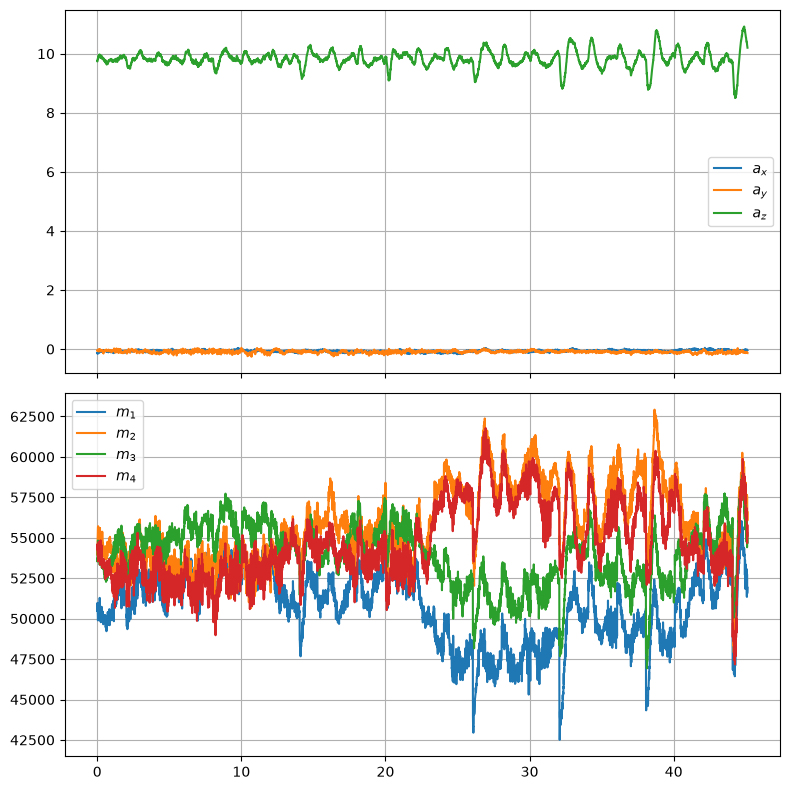

In [72]:
fig, (ax_a, ax_m) = plt.subplots(2, 1, figsize=(8, 8), sharex=True, tight_layout=True)
ax_a.plot(t, a_x, label=r'$a_x$')
ax_a.plot(t, a_y, label=r'$a_y$')
ax_a.plot(t, a_z, label=r'$a_z$')
ax_a.legend()
ax_a.grid()
ax_m.plot(t, m_1, label=r'$m_1$')
ax_m.plot(t, m_2, label=r'$m_2$')
ax_m.plot(t, m_3, label=r'$m_3$')
ax_m.plot(t, m_4, label=r'$m_4$')
ax_m.legend()
ax_m.grid()

### 3.3 Apply linear regression to estimate $k_F$ and $T_F$

Write a function to estimate $k_F$ for a given $T_F$.

In [73]:
def estimate_force_parameter(T_F):
    # Compute x(t)
    x = m_1 + m_2 + m_3 + m_4

    # Compute y(t)
    y = m * a_z

    # Compute y(t + T_F)
    y = np.interp(t + T_F, t, y)

    # Compute estimate
    k_F = np.sum(x * y) / np.sum(x**2)

    # Compute RMSE
    RMSE = np.sqrt(np.mean((y - k_F * x)**2))

    return k_F, RMSE, x, y

Find the RMSE for a range of $T_F$.

In [74]:
# Create an array with a range of T_F's
T_Fs = np.linspace(0., 0.2, 401)

# Create an array to hold the RMSE for each T_F
RMSEs = np.empty_like(T_Fs)

# Find the RMSE for each T_F
for i, T_F in enumerate(T_Fs):
    k_F, RMSEs[i], x, y = estimate_force_parameter(T_F)

Find the value of $T_F$ that gives the minimum RMSE.

In [75]:
# Find the index of the minimum RMSE
i = np.argmin(RMSEs)

# Find the minimum RMSE
RMSE = RMSEs[i]

# Find the time shift that gives the minimum RMSE
T_F = T_Fs[i]

Plot the RMSE for a range of $T_F$, showing the minimum.

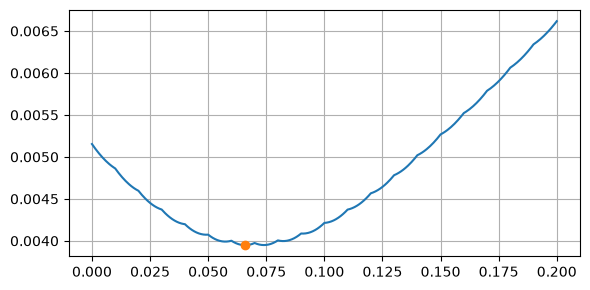

In [76]:
fig, ax = plt.subplots(1, 1, figsize=(6, 3), tight_layout=True)
ax.plot(T_Fs, RMSEs)
ax.plot(T_F, RMSE, '.', markersize=12)
ax.grid()

Recompute the estimate of $k_F$ for the value of $T_F$ that results in minimum RMSE.

In [77]:
k_F, RMSE, x, y = estimate_force_parameter(T_F)

Show the estimate.

In [78]:
print(f'k_F = {k_F:.2e}')
print(f'T_F = {T_F:.3f}')

k_F = 1.46e-06
T_F = 0.066


### 3.4 Validate your estimate

Show a plot that compares the predicted value of $f_z$ (i.e., $k_F x(t)$) with the measured value of $f_Z$ (i.e., $y(t + T_F)$), both as functions of $t$.

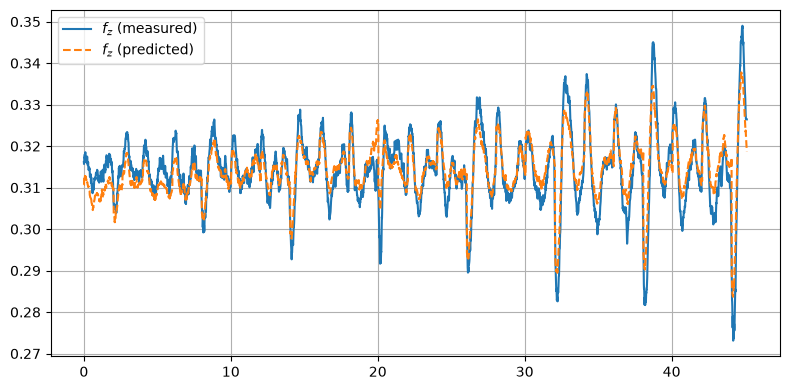

In [79]:
fig, ax = plt.subplots(1, 1, figsize=(8, 4), tight_layout=True)
ax.plot(t, y, label=r'$f_z$ (measured)')
ax.plot(t, k_F * x, '--', label=r'$f_z$ (predicted)')
ax.legend()
ax.grid()

Show a plot that compares the linear fit (i.e., $k_F x(t)$) to the raw data (i.e., $y(t + T_F)$), both as functions of $x(t)$.

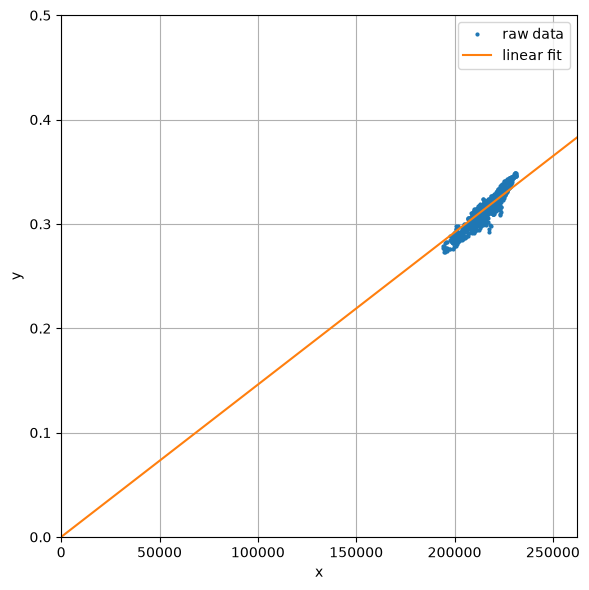

In [80]:
fig, ax = plt.subplots(1, 1, figsize=(6, 6), tight_layout=True)
ax.plot(x, y, '.', markersize=4, label='raw data')
ax.plot([0, 262140], [k_F * 0, k_F * 262140], label='linear fit')
ax.set_xlim(0, 262140)
ax.set_xlabel('x')
ax.set_ylim(0, 0.5)
ax.set_ylabel('y')
ax.legend()
ax.grid()

## 4. Find the moment parameter

### 4.1 Describe the flight

**Modify the text in this cell** to give a precise description of the flight trajectory, both in words and with the relevant code from `flight.py` (i.e., the sequence of stop and move commands). Please include code in markdown with a "code block" that is delimited by three backslashes above and below — for example, this...

``````
```python
drone_client.move(0.0, 0.0, 0.5, 0.0, 1.0)
```
``````
...is rendered like this:
```python
drone_client.move(0.0, 0.0, 0.5, 0.0, 1.0)
```

### 4.2 Get and plot flight data

Load and resample data.

In [81]:
# Load data
raw_data_drone, raw_data_mocap, raw_data_bodies = load_hardware_data('moment_data.json')

# Resample data
data_drone = resample_data_drone(
    raw_data_drone,
    t_min_offset=15.,    # <-- FIXME
    t_max_offset=15.,    # <-- FIXME
)

Parse data to get:
* time
* the gyroscope measurements (**note!** these are in units of degrees / second)
* the motor power commands

In [82]:
t = data_drone['time']
w_x = np.deg2rad(data_drone['gyro.x'])
w_y = np.deg2rad(data_drone['gyro.y'])
w_z = np.deg2rad(data_drone['gyro.z'])
m_1 = data_drone['motor.m1']
m_2 = data_drone['motor.m2']
m_3 = data_drone['motor.m3']
m_4 = data_drone['motor.m4']

Find the time step. It should be `0.01` because data were sampled at 100 Hz. (If it is not, stop and fix the problem.)

In [83]:
dt = t[1] - t[0]
print(f'dt = {dt}')

dt = 0.01


Plot gyroscope measurements and motor power commands, and check two things:
* Check that the $x$ and $y$ gyroscope measurements are much smaller than the $z$ gyroscope measurements. We would expect this to be true, because the drone was near hover during flight (only yawing back and forth). If this is not true, then something is wrong — fix the problem before going any further.
* Check that you are only seeing data from when the drone was *actually flying*. If this is not true, go back and adjust `t_min_offset` and `t_max_offset`.

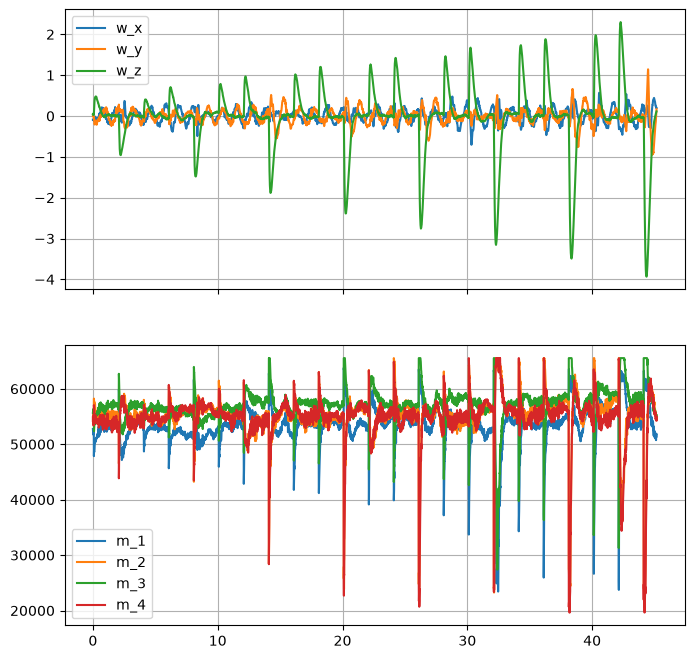

In [84]:
fig, (ax_w, ax_m) = plt.subplots(2, 1, figsize=(8, 8), sharex=True)
ax_w.plot(t, w_x, label='w_x')
ax_w.plot(t, w_y, label='w_y')
ax_w.plot(t, w_z, label='w_z')
ax_w.legend()
ax_w.grid()
ax_m.plot(t, m_1, label='m_1')
ax_m.plot(t, m_2, label='m_2')
ax_m.plot(t, m_3, label='m_3')
ax_m.plot(t, m_4, label='m_4')
ax_m.legend()
ax_m.grid()

### 4.3 Use finite difference to estimate $\dot{w}_z$

Estimate $\dot{w}_z$ by finite difference.

In [85]:
w_z_dot = np.diff(w_z) / np.diff(t) # <-- FIXME (REPLACE WITH CODE TO COMPUTE W_Z_DOT BY FINITE DIFFERENCE)

Truncate all other data so that everything has the same length.

In [86]:
# FIXME (REPLACE WITH CODE TO MODIFY t, m_1, etc.)
t = t[:-1]
w_z = w_z[:-1]

m_1 = m_1[:-1]
m_2 = m_2[:-1]
m_3 = m_3[:-1]
m_4 = m_4[:-1]

Plot both $w_z$ and $\dot{w}_z$ as a check to make sure finite difference was implemented correctly. (What should the sign of $\dot{w}_z$ be when $w_z$ is increasing, for example?)

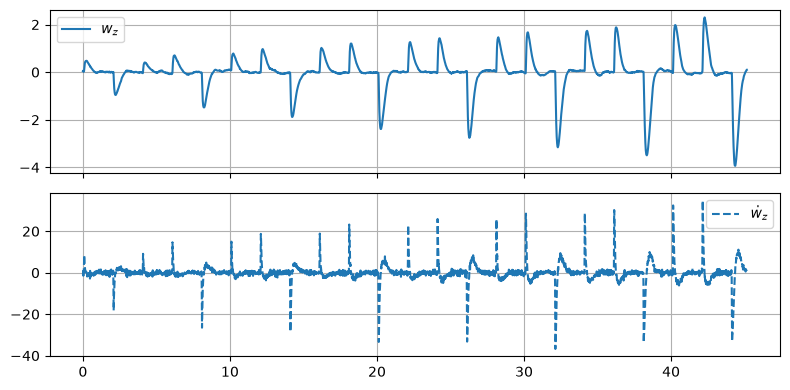

In [87]:
fig, (ax_w_z, ax_w_z_dot) = plt.subplots(2, 1, figsize=(8, 4), sharex=True, tight_layout=True)
ax_w_z.plot(t, w_z, label=r'$w_z$')
ax_w_z.legend()
ax_w_z.grid()
ax_w_z_dot.plot(t, w_z_dot, '--', label=r'$\dot{w}_z$')
ax_w_z_dot.legend()
ax_w_z_dot.grid()

### 4.4 Apply linear regression to estimate $k_M$ and $T_M$

Write a function to estimate $k_M$ for a given $T_M$.

In [88]:
def estimate_kM(T_M):
    # Compute x(t)
    x = -m_1 + m_2 - m_3 + m_4

    # Compute y(t)
    y = J_z * w_z_dot

    # Compute y(t + T_M)
    y = np.interp(t + T_M, t, y)

    # Compute estimate
    k_M = np.sum(x * y) / np.sum(x**2)

    # Compute RMSE
    RMSE = np.sqrt(np.mean((y - k_M * x)**2))

    return k_M, RMSE, x, y

Find the RMSE for a range of $T_M$.

In [89]:
# Create an array with a range of T's
T_Ms = np.linspace(0., 0.2, 401)

# Create an array to hold the RMSE for each T
RMSEs = np.empty_like(T_Ms)

# Find the RMSE for each T_M
for i, T_M in enumerate(T_Ms):
    k_M, RMSEs[i], x, y = estimate_kM(T_M)

Find the value of $T_M$ that gives the minimum RMSE.

In [90]:
# Find the index of the minimum RMSE
i = np.argmin(RMSEs)

# Find the minimum RMSE
RMSE = RMSEs[i]

# Find the time shift that gives the minimum RMSE
T_M = T_Ms[i]

Plot the RMSE for a range of $T_M$, showing the minimum.

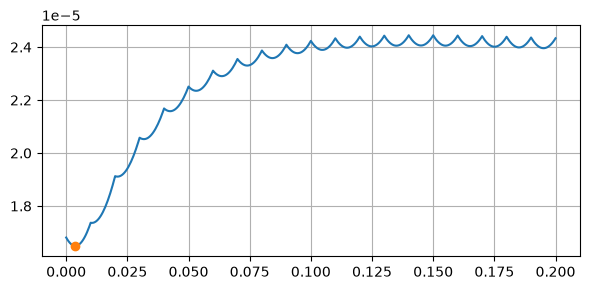

In [91]:
fig, ax = plt.subplots(1, 1, figsize=(6, 3), tight_layout=True)
ax.plot(T_Ms, RMSEs)
ax.plot(T_M, RMSE, '.', markersize=12)
ax.grid()

Recompute the estimate of $k_F$ for the value of $T_M$ that results in minimum RMSE.

In [92]:
k_M, RMSE, x, y = estimate_kM(T_M)


Show the estimate.

In [93]:
print(f'k_M = {k_M:.2e}')
print(f'T_M = {T_M:.3f}')

k_M = 1.25e-09
T_M = 0.004


### 4.5 Validate your estimate

Show a plot that compares the predicted value of $\tau_z$ (i.e., $k_M x(t)$) with the measured value of $\tau_Z$ (i.e., $y(t + T_M)$), both as functions of $t$.

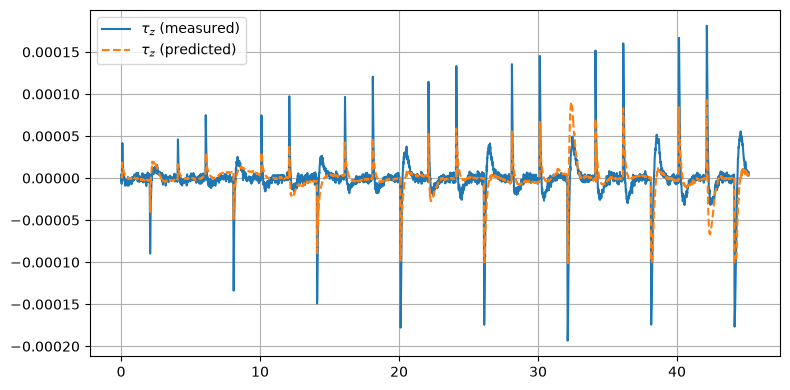

In [94]:
fig, ax = plt.subplots(1, 1, figsize=(8, 4), tight_layout=True)
ax.plot(t, y, label=r'$\tau_z$ (measured)')
ax.plot(t, k_M * x, '--', label=r'$\tau_z$ (predicted)')
ax.legend()
ax.grid()

Show a plot that compares the linear fit (i.e., $k_M x$ versus $x$) to the raw data (i.e., $y(t + T_M)$ versus $x(t)$).

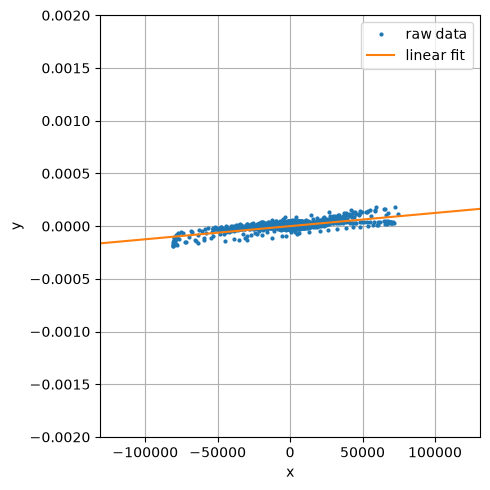

In [95]:
fig, ax = plt.subplots(1, 1, figsize=(5, 5), tight_layout=True)
ax.plot(x, y, '.', markersize=4, label='raw data')
ax.plot([-131070, 131070], [k_M * -131070, k_M * 131070], label='linear fit')
ax.set_xlim(-131070, 131070)
ax.set_xlabel('x')
ax.set_ylim(-.002, 0.002)
ax.set_ylabel('y')
ax.legend()
ax.grid()

## 5. Summarize and discuss the results

### 5.1 Summary of results

In [96]:
print(f'l = {l:.3f} m')
print(f'k_F = {k_F:.2e} N  (T_F = {T_F:.3f} s)')
print(f'k_M = {k_M:.2e} N  (T_M = {T_M:.3f} s)')

l = 0.032 m
k_F = 1.46e-06 N  (T_F = 0.066 s)
k_M = 1.25e-09 N  (T_M = 0.004 s)


### 5.2 Conclusions about time delay

**Modify the text in this cell** to answer the following questions about your results:

* What is the delay between the time at which a motor command is given and the time at which the corresponding rotor produces a force along the $z_B$ axis? Do you consider this delay to be significant?

Along the z axis, the time delay is 0.074 seconds, or 74ms. For compairison, the average human reaction time is 100-200 ms. This delay is significant because the drone does not immediately respond to changes in motor commands. Although 74 ms is relatively short (to us), it could affect the controller's ability to make quick altitude corrections, potentially causing overshoot or oscillations.

* What is the delay between the time at which a motor command is given and the time at which the corresponding rotor produces a moment about the $z_B$ axis? Do you consider this delay to be significant?

The measured time delay is 0.004 s, or 4 ms. This is much shorter than the force delay and is likely insignificant for our drone's control system. The rotor produces the yaw moment almost immediately after receiving a motor command, so this delay should have relatively little impact on yaw control.

Then, based on your answers to these first two questions, answer four more:

* What delay would you expect between the time at which your controller asks for a net torque $\tau_x$ and the time at which that torque is produced? Do you consider this delay to be significant?

I would expect a delay of approximately 74 ms, the same as $T_F$. Roll torque is generated by differences in thrust between motors, with the thrust acting through a moment arm $l = 0.032$ m. Since roll torque depends on rotor thrust, it should experience the same delay. This delay is significant because it could slow roll corrections and affect the drone's stability during rapid maneuvers.

* What delay would you expect between the time at which your controller asks for a net torque $\tau_y$ and the time at which that torque is produced? Do you consider this delay to be significant?

Similarly, I would expect a delay of approximately 74 ms for pitch torque. Like roll, pitch torque is generated by differences in rotor thrust acting through a moment arm. Therefore, it should experience the same delay as the force response. This could noticeably affect how quickly the drone corrects its pitch angle and potentially lead to overshoot.

* What delay would you expect between the time at which your controller asks for a net torque $\tau_z$ and the time at which that torque is produced? Do you consider this delay to be significant?

I would expect a delay of approximately 4 ms, corresponding to $T_M$. Unlike roll and pitch, yaw torque is generated by the reaction torques of the spinning rotors rather than differences in thrust acting through moment arms. Therefore, yaw torque should follow the measured moment delay. This delay is relatively small and is unlikely to significantly affect yaw control under our test conditions.

* What delay would you expect between the time at which your controller asks for a net force $f_z$ and the time at which that force is produced? Do you consider this delay to be significant?

I would expect a delay of approximately 74 ms, corresponding to $T_F$. The net vertical force is the sum of the thrust forces produced by all four rotors. Since each rotor experiences a delay in producing thrust, the total force should experience approximately the same delay. This is significant for altitude control, as the drone cannot immediately produce the requested thrust, potentially affecting its ability to maintain a steady hover or respond to sudden changes in altitude.

Please justify your answers (don't just say "yes" or "no").

### 5.3 Sources of error

**Modify the text in this cell** to discuss possible sources of error. For example:

* How uncertain was each measurement and each computed quantity?
* What assumptions were made and to what extent were these assumptions violated?

You may find that these questions are harder to answer than in the previous lab.

There are several possible sources of error in our estimates of the force and moment coefficients, $k_F$ and $k_M$, and their respective time delays.
1. Sensor noise and measurement uncertainty: The accelerometer and gyroscope measurements contain noise, which affects the accuracy of the calculated force and moment. This is especially important for $k_M$, since angular acceleration was calculated using finite differences of the gyroscope measurements. Numerical differentiation can amplify noise, introducing additional uncertainty.
2. Near-hover assumption: Our model assumes the drone is operating near hover, with relatively small angular velocities and translational velocities. However, during the altitude and yaw tests, the drone was actively accelerating and rotating, which could violate these assumptions. As a result, some terms neglected in the equations of motion may have affected our estimates.
3. Linear motor model: We assumed that the forces and moments produced by the motors are linearly proportional to their motor commands, with constant coefficients $k_F$ and $k_M$. In reality, the relationship may not be perfectly linear, particularly at different motor speeds. This could introduce errors into our linear regression.
4. Time delay estimation: The time delays were determined by finding the values of $T_F$ and $T_M$ that minimized the RMSE. Their accuracy depends on the sampling rate, measurement noise, and the range of time shifts tested. Interpolation also introduces some uncertainty. Therefore, the estimated delays of 74 ms and 4 ms may not represent the exact physical delays.
5. Physical parameter uncertainty: The drone's mass, moment of inertia $J_z$, and motor arm length $l$ were treated as known constants. Any uncertainty in these values could affect the calculated coefficients. In particular, uncertainty in $J_z$ directly affects the estimate of $k_M$.
Overall, it is difficult to assign exact numerical uncertainties without additional information about sensor accuracy, sampling rates, and measurement variability. However, the estimated coefficients and delays provide an approximate representation of the drone's behavior. The main sources of uncertainty are likely sensor noise, simplifications in the near-hover model, and the assumption of a linear relationship between motor commands and their resulting forces and moments.

### 5.4 Ways to improve the results

**Modify the text in this cell** to propose at least one way in which the experiments or the analysis could be improved to get estimates of $k_F$ and $k_M$ (as well as $T_F$ and $T_M$) that are more accurate (i.e., less uncertain). You could suggest improvements to your current method of approach, but you are also welcome to suggest a completely different method of approach.

One way to improve the accuracy of our estimates would be to repeat each experiment multiple times and average the results. This would help reduce the effects of random sensor noise and allow us to calculate the standard deviation of our estimates, giving us a better understanding of their uncertainty.
Another improvement would be to increase the sampling rate and filter the sensor data. This would be especially useful for estimating $k_M$, since the angular acceleration is calculated using finite differences, which can amplify measurement noise. Applying a low-pass filter to the gyroscope data before differentiation could help reduce this error. A higher sampling rate could also improve the resolution of our estimated time delays, particularly the relatively small $T_M = 0.004$ s.
Finally, we could improve the experiment by testing the motors over a wider range of commands and using a more detailed motor model. Our current analysis assumes a linear relationship between motor commands and the resulting forces and moments. Testing different motor commands could help determine whether this assumption is valid. Alternatively, measuring individual motor thrust and torque on a test stand would allow us to estimate $k_F$ and $k_M$ more directly, without relying on the drone's flight dynamics. Step-input tests with synchronized motor-command and sensor measurements could also help identify $T_F$ and $T_M$ more accurately.

### 5.5 Reflection

Review the reflection you put in your Lab 3 notebook. **Modify the text in this cell** to answer the following three questions with at least one sentence each:
* What was your biggest struggle this week? Was it the same or different from last week?
    Dan my partner left me behind so i had to do it myself
* What was the most important thing you learned this week?
    even just a linear model can approximate pretty well
* How does what you learned this week relate to what you learned last week?
    When working in the real world, assumptions have to be made, and sometimes you dont have to be perfect.

    